# 07 ตัวอย่างแนวคิด SACIT: ภาพรวมผลิตภัณฑ์ศิลปหัตถกรรมไทย

Notebook นี้เป็นตัวอย่างเสริม ไม่ใช่ส่วนหนึ่งของข้อสรุป LABAI หลัก ใช้ไฟล์ raw ของ SACIT ที่ดาวน์โหลดไว้จริงเพื่อสาธิตการตรวจ schema และกราฟพื้นฐานจาก column ที่อ่านได้

ไม่สร้าง forecasting หรือ model ใน notebook นี้ เพราะความพร้อมของข้อมูลเวลาต้องตรวจจากไฟล์จริงก่อน

## 00 แหล่งข้อมูลและขอบเขต

ใช้ชุดข้อมูลภาพรวมรายงานผลิตภัณฑ์ศิลปหัตถกรรมไทยจากสถาบันส่งเสริมศิลปหัตถกรรมไทย (องค์การมหาชน)

- Metadata: https://data.go.th/dataset/sacit_hs_03
- Resource ที่บันทึกในโครงการ: https://catalog.sacit.or.th/dataset/c3f38839-e672-4045-a69b-47acc3b84413/resource/51da546b-e324-4ba2-b0e6-58eb912db3ea/download/1-68.csv
- ไฟล์ local: `data/raw/sacit_craft_product_overview_2568.csv`

ผลใน notebook นี้อธิบายเฉพาะไฟล์ที่ดาวน์โหลดไว้ ไม่ใช่การสรุปการส่งออกหรือผลการดำเนินงานของ SACIT ทั้งหมด

## 01 นำเข้าไลบรารี

ใช้ pandas สำหรับอ่านและตรวจข้อมูล, Matplotlib สำหรับกราฟตัวอย่าง และ Path สำหรับระบุตำแหน่งไฟล์

In [1]:
from pathlib import Path
import os
import re
import tempfile

## 02 ค้นหา root ของโครงการ

รองรับการรันจาก root ของโครงการหรือจากโฟลเดอร์ notebook โดยตรวจหา `data/raw/` ที่มีอยู่จริง

In [2]:
def find_project_root():
    current_path = Path.cwd().resolve()
    candidate_paths = [current_path]
    candidate_paths.extend(current_path.parents)

    for candidate_path in candidate_paths:
        if (candidate_path / "data" / "raw").exists():
            return candidate_path

    raise FileNotFoundError("ไม่พบ root ของโครงการที่มี data/raw")


PROJECT_ROOT = find_project_root()


## 03 ตั้งค่า runtime สำหรับกราฟ

กำหนด cache และ backend แบบ non-interactive ใน workspace ก่อน import Matplotlib เพื่อให้รันได้ใน environment ที่ไม่มี GUI

In [3]:
MPL_CONFIG_DIR = Path(tempfile.gettempdir()) / "dga306_matplotlib_cache"
MPL_CONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPL_CONFIG_DIR))
os.environ.setdefault("MPLBACKEND", "Agg")

'module://matplotlib_inline.backend_inline'

## 04 นำเข้าไลบรารีสำหรับข้อมูลและกราฟ

import Matplotlib หลังตั้งค่า runtime แล้ว และใช้ pandas สำหรับอ่านข้อมูลจริง

In [4]:
from io import BytesIO
from IPython.display import Image, display
import matplotlib as mpl
mpl.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd

## 05 ตั้งค่า font สำหรับกราฟภาษาไทย

ใช้ไฟล์ Sarabun ที่มีอยู่ใน root ของโครงการ หากไม่พบจะใช้ font มาตรฐานของระบบเพื่อให้ notebook ยังรันได้ แต่ข้อความไทยอาจแสดงไม่สมบูรณ์

In [5]:
FONT_FILE = PROJECT_ROOT / "Sarabun-Regular.ttf"

if FONT_FILE.exists():
    mpl.font_manager.fontManager.addfont(str(FONT_FILE))
    plt.rcParams["font.family"] = "Sarabun"
else:
    plt.rcParams["font.family"] = "sans-serif"

plt.rcParams["axes.unicode_minus"] = False

## 06 กำหนดตำแหน่ง input และ output

ชื่อไฟล์ raw เป็นชื่อที่ตรวจพบในโครงการ และกราฟตัวอย่างจะแสดงใน output ของ notebook โดยไม่บันทึกไฟล์เพิ่ม


In [6]:
RAW_FILE = PROJECT_ROOT / "data" / "raw" / "sacit_craft_product_overview_2568.csv"

## 07 ตรวจไฟล์ต้นทาง

ตรวจเฉพาะการมีอยู่ของไฟล์ก่อนอ่าน เพื่อไม่สร้างข้อมูลแทนไฟล์จริงเมื่อ resource ไม่พร้อม

In [7]:
if not RAW_FILE.exists():
    raise FileNotFoundError(f"ไม่พบไฟล์ SACIT: {RAW_FILE}")

raw_file_status = pd.DataFrame(
    {
        "รายการ": ["ไฟล์ raw", "ที่อยู่ local"],
        "ค่า": [RAW_FILE.name, str(RAW_FILE.relative_to(PROJECT_ROOT))],
    }
)
raw_file_status

,รายการ,ค่า
0,ไฟล์ raw,sacit_craft_product_overview_2568.csv
1,ที่อยู่ local,data\raw\sacit_craft_product_overview_2568.csv


## 08 โหลดข้อมูล raw

CSV นี้อ่านด้วย `utf-8-sig` ตามผล schema audit เดิม และยังไม่เปลี่ยนชื่อ column หรือเติมค่าที่ขาด

In [8]:
sacit_export_raw_df = pd.read_csv(RAW_FILE, encoding="utf-8-sig")
sacit_export_raw_df.head()

,ลำดับ,รายการสินค้า,ม.ค.68,ก.พ.68,มี.ค.68,เม.ย.68,พ.ค.68,มิ.ย.68,ก.ค.68,ส.ค.68,ก.ย.68,ต.ค.68,พ.ย.68,ธ.ค.68
0,1.0,เสื้อผ้าสำเร็จรูปทำจากฝ้าย,"1,386.90","1,327.51","1,246.68","1,275.86","1,621.29","1,399.94","1,626.16","1,358.89",NaN,NaN,NaN,NaN
1,2.0,เสื้อผ้าสำเร็จรูปทำจากไหม,3.27,3.50,7.54,8.06,4.15,10.60,29.84,21.62,NaN,NaN,NaN,NaN
2,3.0,เสื้อผ้าสำเร็จรูปทำจากวัตถุทออื่น ๆ,"1,405.81","1,707.65","1,510.89","1,334.68","1,579.62","1,712.56","1,487.03","1,421.57",NaN,NaN,NaN,NaN
3,4.0,ผ้าผืนทำจากฝ้าย,707.57,752.03,708.90,618.99,596.01,628.88,750.37,569.49,NaN,NaN,NaN,NaN
4,5.0,ผ้าผืนทำจากไหม,5.88,4.31,6.25,7.89,7.45,4.54,7.30,5.42,NaN,NaN,NaN,NaN


## 09 ตรวจ schema ที่อ่านได้จริง

ตารางนี้แสดงชื่อ column, data type และจำนวนค่าที่ขาดจากไฟล์ปัจจุบัน เพื่อยืนยันว่ากราฟต่อไปใช้ข้อมูลที่มีอยู่จริง

In [9]:
export_schema_review_df = pd.DataFrame(
    {
        "column": sacit_export_raw_df.columns,
        "data_type": [str(data_type) for data_type in sacit_export_raw_df.dtypes],
        "missing_count": [int(sacit_export_raw_df[column].isna().sum()) for column in sacit_export_raw_df.columns],
    }
)
export_schema_review_df

,column,data_type,missing_count
0,ลำดับ,float64,1
1,รายการสินค้า,str,0
2,ม.ค.68,str,0
3,ก.พ.68,str,0
4,มี.ค.68,str,0
5,เม.ย.68,str,0
6,พ.ค.68,str,0
7,มิ.ย.68,str,0
8,ก.ค.68,str,0
9,ส.ค.68,str,0


## 10 ระบุ column เดือนจากรูปแบบชื่อที่ตรวจพบ

เลือกเฉพาะชื่อ column ที่ลงท้ายด้วยปีสองหลักหลังจุด เช่นรูปแบบเดือนที่มีในไฟล์นี้ ไม่กำหนดรายชื่อเดือนขึ้นเอง

In [10]:
month_name_pattern = re.compile(r".+\.\d{2}$")
month_columns = [
    str(column)
    for column in sacit_export_raw_df.columns
    if month_name_pattern.fullmatch(str(column))
]

product_column = "รายการสินค้า"

if product_column not in sacit_export_raw_df.columns:
    raise KeyError("ไม่พบ column รายการสินค้าที่ตรวจไว้ในไฟล์ SACIT")

if not month_columns:
    raise ValueError("ไม่พบ column เดือนตามรูปแบบที่ตรวจจากไฟล์")

month_column_review_df = pd.DataFrame({"month_column": month_columns})
month_column_review_df

,month_column
0,ม.ค.68
1,ก.พ.68
2,มี.ค.68
3,เม.ย.68
4,พ.ค.68
5,มิ.ย.68
6,ก.ค.68
7,ส.ค.68
8,ก.ย.68
9,ต.ค.68


## 11 แปลงค่าตัวเลขของเดือนโดยเก็บ column ต้นฉบับ

ค่ารายเดือนในไฟล์มี comma และบางค่าเป็น missing จึงสร้าง column ลงท้าย `_numeric` เพื่อใช้รวมเฉพาะค่าที่อ่านเป็นตัวเลขได้

In [11]:
sacit_export_numeric_df = sacit_export_raw_df.copy()
numeric_month_columns = []

for month_column in month_columns:
    numeric_column = f"{month_column}_numeric"
    cleaned_month_value = (
        sacit_export_numeric_df[month_column]
        .astype("string")
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    sacit_export_numeric_df[numeric_column] = pd.to_numeric(
        cleaned_month_value,
        errors="coerce",
    )
    numeric_month_columns.append(numeric_column)

sacit_export_numeric_df[[product_column, *numeric_month_columns]].head()

,รายการสินค้า,ม.ค.68_numeric,ก.พ.68_numeric,มี.ค.68_numeric,เม.ย.68_numeric,พ.ค.68_numeric,มิ.ย.68_numeric,ก.ค.68_numeric,ส.ค.68_numeric,ก.ย.68_numeric,ต.ค.68_numeric,พ.ย.68_numeric,ธ.ค.68_numeric
0,เสื้อผ้าสำเร็จรูปทำจากฝ้าย,1386.9,1327.51,1246.68,1275.86,1621.29,1399.94,1626.16,1358.89,<NA>,<NA>,<NA>,<NA>
1,เสื้อผ้าสำเร็จรูปทำจากไหม,3.27,3.5,7.54,8.06,4.15,10.6,29.84,21.62,<NA>,<NA>,<NA>,<NA>
2,เสื้อผ้าสำเร็จรูปทำจากวัตถุทออื่น ๆ,1405.81,1707.65,1510.89,1334.68,1579.62,1712.56,1487.03,1421.57,<NA>,<NA>,<NA>,<NA>
3,ผ้าผืนทำจากฝ้าย,707.57,752.03,708.9,618.99,596.01,628.88,750.37,569.49,<NA>,<NA>,<NA>,<NA>
4,ผ้าผืนทำจากไหม,5.88,4.31,6.25,7.89,7.45,4.54,7.3,5.42,<NA>,<NA>,<NA>,<NA>


## 12 สรุปค่าที่อ่านเป็นตัวเลขได้รายเดือน

ผลรวมนี้รวมเฉพาะค่าที่แปลงเป็นตัวเลขได้ในแต่ละ column และไม่ตีความหน่วยหรือความหมายของค่าเกิน metadata ที่มี

In [12]:
monthly_summary_records = []

for month_column, numeric_column in zip(month_columns, numeric_month_columns):
    numeric_values = sacit_export_numeric_df[numeric_column]
    monthly_summary_records.append(
        {
            "month_column": month_column,
            "observed_numeric_rows": int(numeric_values.notna().sum()),
            "missing_rows": int(numeric_values.isna().sum()),
            "sum_of_observed_values": numeric_values.sum(min_count=1),
        }
    )

monthly_value_summary_df = pd.DataFrame(monthly_summary_records)
monthly_value_summary_df

,month_column,observed_numeric_rows,missing_rows,sum_of_observed_values
0,ม.ค.68,29,0,153025.78
1,ก.พ.68,29,0,183195.60
2,มี.ค.68,29,0,135122.00
3,เม.ย.68,29,0,101141.24
4,พ.ค.68,29,0,109007.78
5,มิ.ย.68,29,0,93972.20
6,ก.ค.68,29,0,105902.44
7,ส.ค.68,29,0,106348.04
8,ก.ย.68,1,28,0.00
9,ต.ค.68,1,28,0.00


## 13 เลือกเดือนที่มีค่าตัวเลขสำหรับกราฟ

แยกเฉพาะ column ที่มีค่าตัวเลขอย่างน้อยหนึ่งแถว เพื่อไม่สร้างจุดข้อมูลจากเดือนที่ไม่มีค่าบันทึก

In [13]:
available_month_summary_df = monthly_value_summary_df[
    monthly_value_summary_df["observed_numeric_rows"] > 0
].copy()
available_month_summary_df

,month_column,observed_numeric_rows,missing_rows,sum_of_observed_values
0,ม.ค.68,29,0,153025.78
1,ก.พ.68,29,0,183195.60
2,มี.ค.68,29,0,135122.00
3,เม.ย.68,29,0,101141.24
4,พ.ค.68,29,0,109007.78
5,มิ.ย.68,29,0,93972.20
6,ก.ค.68,29,0,105902.44
7,ส.ค.68,29,0,106348.04
8,ก.ย.68,1,28,0.00
9,ต.ค.68,1,28,0.00


## 14 สร้างกราฟตัวอย่างของค่ารวมที่สังเกตได้

กราฟนี้ตอบคำถามว่า column เดือนใดมีค่าตัวเลขรวมที่อ่านได้ในไฟล์ ไม่ใช่กราฟ forecasting และไม่ยืนยันหน่วยของค่ารวม

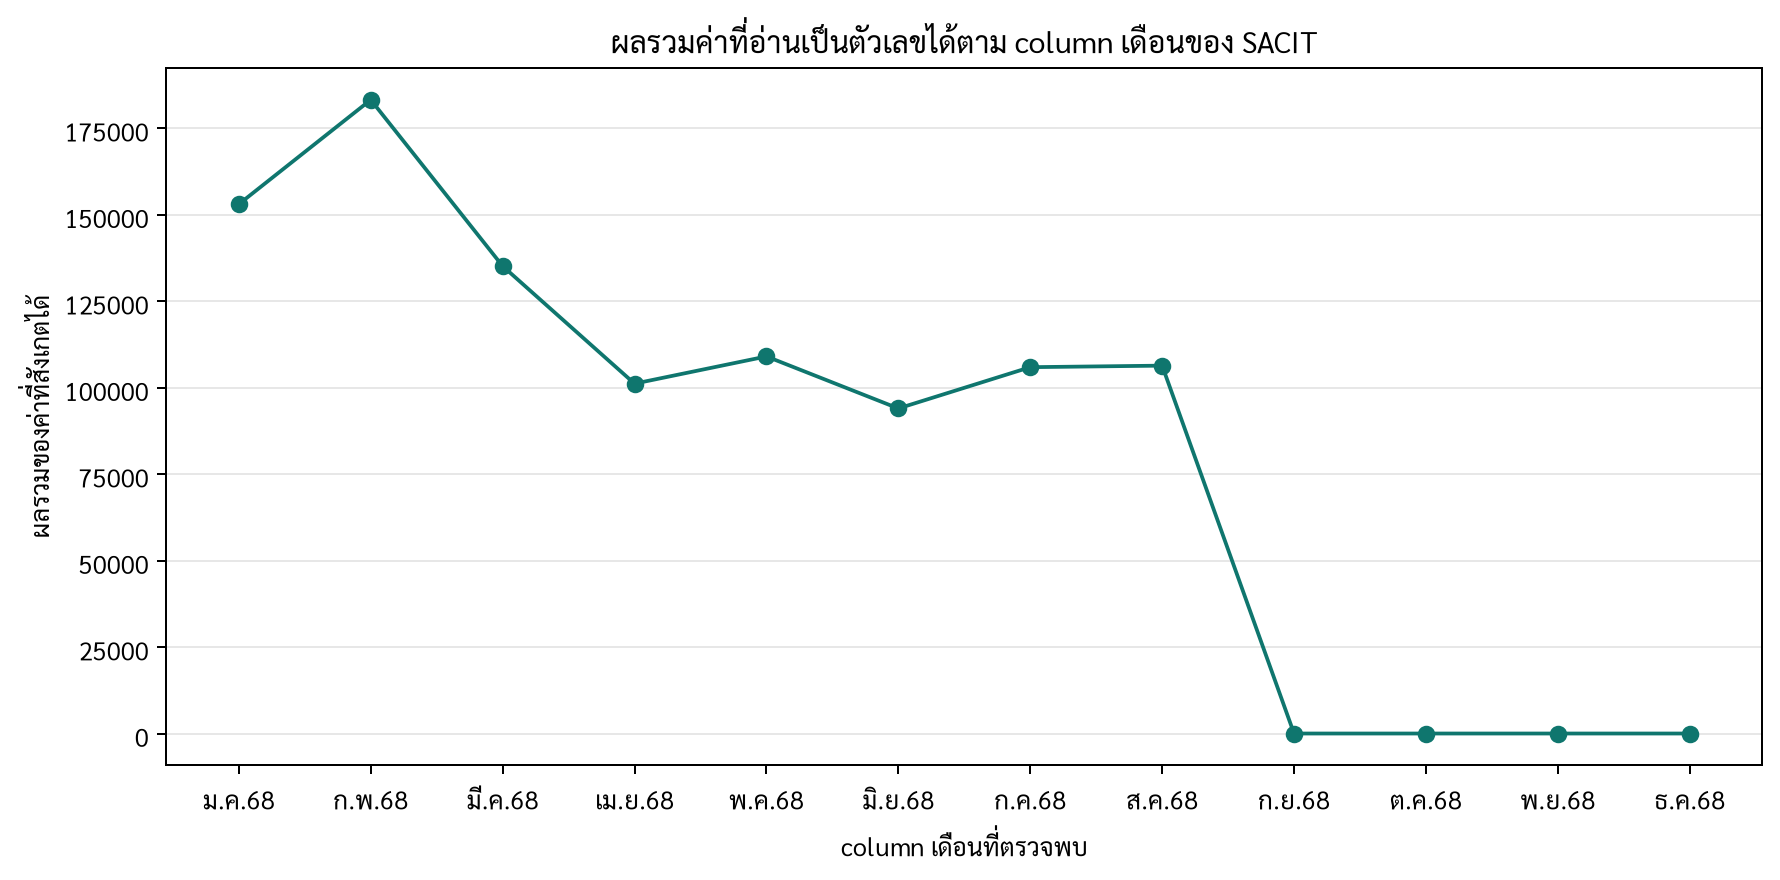

In [14]:
figure, axis = plt.subplots(figsize=(10, 5))

if available_month_summary_df.empty:
    axis.text(0.5, 0.5, "ไม่พบค่าตัวเลขรายเดือนสำหรับสร้างกราฟ", ha="center", va="center")
    axis.set_axis_off()
else:
    axis.plot(
        available_month_summary_df["month_column"],
        available_month_summary_df["sum_of_observed_values"],
        marker="o",
        color="#0f766e",
    )
    axis.set_title("ผลรวมค่าที่อ่านเป็นตัวเลขได้ตาม column เดือนของ SACIT")
    axis.set_xlabel("column เดือนที่ตรวจพบ")
    axis.set_ylabel("ผลรวมของค่าที่สังเกตได้")
    axis.grid(axis="y", alpha=0.3)

figure.tight_layout()
buffer = BytesIO()
figure.savefig(buffer, format="png", dpi=180, bbox_inches="tight")
display(Image(data=buffer.getvalue()))
buffer.close()
plt.close(figure)


## 15 ตรวจข้อจำกัดก่อนพิจารณา forecasting

ตรวจจำนวน column เดือนที่มีค่าและจำนวน label ปีที่พบจริง หากข้อมูลมีปีเดียวหรือเดือนขาด ไม่ควรใช้ notebook นี้สร้าง model พยากรณ์

In [15]:
year_tokens = []

for month_column in month_columns:
    year_token = month_column.rsplit(".", 1)[-1]
    if year_token not in year_tokens:
        year_tokens.append(year_token)

if len(year_tokens) < 2:
    forecasting_reason = "พบ label ปีจากชื่อ column น้อยกว่าสองปี จึงยังไม่มี time series หลายปีสำหรับ baseline forecasting"
else:
    forecasting_reason = "พบ label ปีมากกว่าหนึ่งปี แต่ยังต้องตรวจความต่อเนื่อง หน่วย และค่าที่ขาดก่อน forecasting"

forecasting_readiness_df = pd.DataFrame(
    {
        "รายการตรวจ": [
            "จำนวน column เดือนที่ตรวจพบ",
            "จำนวน column เดือนที่มีค่าตัวเลข",
            "label ปีที่พบจากชื่อ column",
            "การตัดสินใจใน notebook ตัวอย่าง",
            "เหตุผล",
        ],
        "ผล": [
            len(month_columns),
            len(available_month_summary_df),
            ", ".join(year_tokens),
            "ไม่สร้าง forecasting model",
            forecasting_reason,
        ],
    }
)
forecasting_readiness_df

,รายการตรวจ,ผล
0,จำนวน column เดือนที่ตรวจพบ,12
1,จำนวน column เดือนที่มีค่าตัวเลข,12
2,label ปีที่พบจากชื่อ column,68
3,การตัดสินใจใน notebook ตัวอย่าง,ไม่สร้าง forecasting model
4,เหตุผล,พบ label ปีจากชื่อ column น้อยกว่าสองปี จึงยัง...


## 16 สรุปการต่อยอด

ข้อมูลนี้สามารถเป็นจุดเริ่มต้นของ descriptive analytics เมื่อยืนยันหน่วย ความหมายของแถว และความครบถ้วนของเดือนแล้ว

ไม่ควรสรุปแนวโน้มหรือพยากรณ์จาก notebook นี้ เพราะไฟล์ที่ตรวจมีข้อจำกัดด้านช่วงเวลาและค่าที่ขาดตามผลในตาราง readiness

## 17 แหล่งข้อมูล

- Metadata: https://data.go.th/dataset/sacit_hs_03
- Resource URL: https://catalog.sacit.or.th/dataset/c3f38839-e672-4045-a69b-47acc3b84413/resource/51da546b-e324-4ba2-b0e6-58eb912db3ea/download/1-68.csv